# ECOM90025 Advanced Data Analysis — Assignment 4

This revision adds Interaction Ridge and Interaction Elastic Net to validation, model comparison, full-training refits and test prediction. Saved outputs have been cleared because the final ranking must be recomputed. Run cells from top to bottom. Kaggle submission defaults to off.


## Part 1 — Data acquisition

The following Kaggle authentication, file-listing, download and extraction structure is kept the same as Assignments 1 and 2. The competition identifier is stored once in `COMPETITION_ID` and reused later for submission.


In [1]:
# Install required Python packages silently for data manipulation, visualization, modelling, and Kaggle API access
%pip install -q kaggle pandas numpy matplotlib plotly scikit-learn statsmodels


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
from kaggle.api.kaggle_api_extended import KaggleApi

# Initialize and authenticate the Kaggle API client using local credentials
api = KaggleApi()
api.authenticate()

# Specify the unique identifier for the target Kaggle competition
COMPETITION_ID = "ecom-90025-2026-sm-2-ada-assignment-and-practice"

# Display header banner for log readability
print("=" * 60)
print(f"Retrieving details for private competition: {COMPETITION_ID}")
print("=" * 60)

# Retrieve the list of dataset files available in the competition repository
print("Files available in this competition:")
files_response = api.competition_list_files(COMPETITION_ID)

# Display each filename and its size
for file in files_response.files:
    file_size = getattr(file, "total_bytes")
    print(f" - {file.name} ({file_size} bytes)")

print("=" * 60)


Retrieving details for private competition: ecom-90025-2026-sm-2-ada-assignment-and-practice
Files available in this competition:
 - submission.csv (11205 bytes)
 - test_data.csv (1577805 bytes)
 - train_data.csv (2413298 bytes)


In [3]:
import zipfile

# Keep the same destination used in Assignments 1 and 2
DESTINATION_PATH = "./week01"
print(f"Starting download for competition: {COMPETITION_ID}")

# Download all competition files
api.competition_download_files(
    competition=COMPETITION_ID,
    path=DESTINATION_PATH
)
print("Download completed successfully.")

# Locate and extract the downloaded ZIP archive
zip_filename = f"{COMPETITION_ID}.zip"
zip_filepath = os.path.join(DESTINATION_PATH, zip_filename)

print("Extracting files...")
with zipfile.ZipFile(zip_filepath, "r") as zip_ref:
    zip_ref.extractall(DESTINATION_PATH)

# Remove the ZIP archive after extraction
os.remove(zip_filepath)
print(f"Files extracted successfully to '{DESTINATION_PATH}' directory.")


Starting download for competition: ecom-90025-2026-sm-2-ada-assignment-and-practice
Download completed successfully.
Extracting files...
Files extracted successfully to './week01' directory.


## Part 2 — Load and check the data

The initial checks follow the Week 1 workflow: dimensions, data types, missing observations, summary statistics and a preview. A separate GIGO check then verifies IDs, columns and the consistency of the training and testing feature sets.


In [4]:
# Import libraries required for data processing, visualisation, model estimation and evaluation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from itertools import combinations
from collections import Counter

from sklearn.linear_model import Lasso, LinearRegression, Ridge, ElasticNet
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import warnings
# Keep convergence warnings visible during model evaluation.


In [5]:
# Load and inspect the training dataset
train_df = pd.read_csv("./week01/train_data.csv")

print(f"Dataset shape: {train_df.shape}\n")

print("--- Info ---")
train_df.info()

print("\n--- Summary Statistics ---")
print(train_df.describe())

print("\n--- Preview (First 5 Rows) ---")
print(train_df.head())


Dataset shape: (2400, 52)

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 52 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Y       2400 non-null   float64
 1   X1      2400 non-null   float64
 2   X2      2400 non-null   float64
 3   X3      2400 non-null   float64
 4   X4      2400 non-null   float64
 5   X5      2400 non-null   float64
 6   X6      2400 non-null   float64
 7   X7      2400 non-null   float64
 8   X8      2400 non-null   float64
 9   X9      2400 non-null   float64
 10  X10     2400 non-null   float64
 11  X11     2400 non-null   float64
 12  X12     2400 non-null   float64
 13  X13     2400 non-null   float64
 14  X14     2400 non-null   float64
 15  X15     2400 non-null   float64
 16  X16     2400 non-null   float64
 17  X17     2400 non-null   float64
 18  X18     2400 non-null   float64
 19  X19     2400 non-null   float64
 20  X20     2400 non-null   float64
 2

In [6]:
# Define the response, candidate predictors and identifier
target_col = "Y"
feature_cols = [f"X{i}" for i in range(1, 51)]
id_col = "ID"

# Load the test sample now only for structural checks.
# It will not be used in model selection or CV.
test_df = pd.read_csv("./week01/test_data.csv")

# Check data structure, missing values and duplicated IDs before modelling
print("--- GIGO / Sanity Checks ---")
print("Training observations:", train_df.shape[0])
print("Testing observations :", test_df.shape[0])
print("Number of predictors :", len(feature_cols))
print("Training missing values:",
      train_df[feature_cols + [target_col]].isna().sum().sum())
print("Testing missing values :",
      test_df[feature_cols].isna().sum().sum())
print("Duplicated training IDs:", train_df[id_col].duplicated().sum())
print("Duplicated testing IDs :", test_df[id_col].duplicated().sum())

assert set(feature_cols + [target_col, id_col]).issubset(train_df.columns)
assert set(feature_cols + [id_col]).issubset(test_df.columns)
assert train_df[feature_cols + [target_col]].isna().sum().sum() == 0
assert test_df[feature_cols].isna().sum().sum() == 0
assert train_df[id_col].duplicated().sum() == 0
assert test_df[id_col].duplicated().sum() == 0

# ID is deliberately excluded because it is an identifier
X_original = train_df[feature_cols].copy()
y = train_df[target_col].copy()
X_original_test = test_df[feature_cols].copy()


--- GIGO / Sanity Checks ---
Training observations: 2400
Testing observations : 1600
Number of predictors : 50
Training missing values: 0
Testing missing values : 0
Duplicated training IDs: 0
Duplicated testing IDs : 0


### Exploratory relationship with (Y)

As in Assignment 1, Pearson correlations provide a quick description of linear association. They are not used alone to choose the final model because correlation examines one variable at a time, misses nonlinearities and is an in-sample description. The final model is selected by five-fold OOS performance.


In [7]:
# Calculate and visualise Pearson correlations between the predictors and the response
correlations = X_original.apply(lambda col: col.corr(y))
corr_df = pd.DataFrame({
    "Feature": feature_cols,
    "Correlation_with_Y": correlations.values
})
corr_df["Absolute_Correlation"] = corr_df["Correlation_with_Y"].abs()
corr_df = corr_df.sort_values(
    "Absolute_Correlation", ascending=False
).reset_index(drop=True)

print("--- Ten strongest marginal correlations ---")
print(corr_df.head(10))

fig = px.bar(
    corr_df.head(15).sort_values("Correlation_with_Y"),
    x="Correlation_with_Y",
    y="Feature",
    orientation="h",
    title="Fifteen strongest marginal correlations with Y"
)
fig.update_layout(
    xaxis_title="Pearson correlation",
    yaxis_title="Predictor"
)
fig.show()


--- Ten strongest marginal correlations ---
  Feature  Correlation_with_Y  Absolute_Correlation
0     X34            0.441090              0.441090
1     X21            0.369724              0.369724
2     X45            0.348339              0.348339
3     X46            0.344771              0.344771
4     X39            0.343533              0.343533
5     X23            0.341101              0.341101
6     X15            0.338810              0.338810
7     X35            0.338243              0.338243
8      X5            0.335470              0.335470
9     X16            0.334653              0.334653


## Part 3 — Statistical framework and evaluation measures

All models remain linear in coefficients: (y_i=x_i'\beta+\varepsilon_i). Nonlinearity is introduced through new regressors such as (X_j^2) and (X_jX_k).

For continuous (Y), Week 3 Gaussian deviance is (D(y,\widehat y)=\sum_i(y_i-\widehat y_i)^2). We report MSE, RMSE, OOS (R^2=1-D/D_0), and fold-MSE standard deviation. Lower deviance/MSE/RMSE is better; higher (R^2) is better.


In [8]:
# Week 3-style deviance and R-squared functions
def deviance(y_true, prediction, family="gaussian"):
    family = family.lower()
    y_true = np.asarray(y_true)
    prediction = np.asarray(prediction)

    if family == "gaussian":
        return np.sum((y_true - prediction) ** 2)

    raise ValueError("Assignment 4 has a continuous Y; use family='gaussian'.")

# Calculate out-of-sample R-squared relative to the mean-only benchmark
def R2(y_true, prediction, family="gaussian"):
    y_true = np.asarray(y_true)
    prediction = np.asarray(prediction)

    model_deviance = deviance(y_true, prediction, family=family)
    null_prediction = np.repeat(np.mean(y_true), len(y_true))
    null_deviance = deviance(y_true, null_prediction, family=family)

    return 1 - model_deviance / null_deviance

# Summarise OOS model performance using MSE, RMSE, R-squared and fold stability
def summarize_oof(model_name, y_true, prediction, fold_mse):
    mse = mean_squared_error(y_true, prediction)

    return {
        "Model": model_name,
        "Gaussian deviance": deviance(y_true, prediction),
        "CV MSE": mse,
        "CV RMSE": np.sqrt(mse),
        "OOS R2": R2(y_true, prediction),
        "Fold MSE SD": np.std(fold_mse)
    }


## Part 4 — Assignment 3 feature construction

The linear set has 50 original terms. The quadratic set adds 50 squares. The interaction set adds all (\binom{50}{2}=1,225) unique pairwise products, producing 1,325 candidates. This is the large-(p) setting that motivates Week 4 LASSO.


In [9]:
def build_feature_sets(df, base_cols):
    linear = df[base_cols].copy()

    squared = pd.DataFrame(
        {f"{col}_sq": df[col] ** 2 for col in base_cols},
        index=df.index
    )

    interactions = pd.DataFrame(
        {
            f"{left}_x_{right}": df[left] * df[right]
            for left, right in combinations(base_cols, 2)
        },
        index=df.index
    )

    quadratic = pd.concat([linear, squared], axis=1)
    full_interaction = pd.concat(
        [linear, squared, interactions], axis=1
    )
    nonlinear_only = pd.concat([squared, interactions], axis=1)

    return linear, quadratic, full_interaction, nonlinear_only


X_linear, X_quadratic, X_interaction, Z_nonlinear = build_feature_sets(
    train_df, feature_cols
)

print("Linear candidate terms     :", X_linear.shape[1])
print("Quadratic candidate terms  :", X_quadratic.shape[1])
print("Interaction candidate terms:", X_interaction.shape[1])
print("Nonlinear-only terms       :", Z_nonlinear.shape[1])

Linear candidate terms     : 50
Quadratic candidate terms  : 100
Interaction candidate terms: 1325
Nonlinear-only terms       : 1275


## Part 5 — Scaling, LASSO and AICc

Week 4 requires scaling before LASSO because the penalty acts on coefficient magnitudes. For every candidate alpha, the code estimates LASSO, calculates MSE, counts non-zero coefficients and selects the minimum AICc:

[
AICc=n\log(MSE)+2df+\frac{2df(df+1)}{n-df-1}.
]

AICc selection is repeated inside each outer training fold, preventing the validation outcomes from entering that fold's variable selection.


In [10]:
# Set up five-fold cross-validation and the candidate alpha grid for LASSO
K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)
folds = list(kf.split(X_linear))
alphas = np.logspace(-4, 0.5, num=30)

# Select the LASSO penalty that minimises AICc and retain the corresponding non-zero features
def select_alpha_by_aicc(X, y, alpha_values, fixed_parameters=0):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    aicc_values = []
    fitted_models = []
    selected_counts = []

    for alpha in alpha_values:
        lasso_model = Lasso(alpha=alpha, max_iter=20000)
        lasso_model.fit(X_scaled, y)

        fitted = lasso_model.predict(X_scaled)
        mse = mean_squared_error(y, fitted)

        nonzero = np.count_nonzero(lasso_model.coef_)
        df = fixed_parameters + nonzero + 1
        denominator = len(y) - df - 1

        if mse <= 0 or denominator <= 0:
            aicc = np.inf
        else:
            aicc = (
                len(y) * np.log(mse)
                + 2 * df
                + 2 * df * (df + 1) / denominator
            )

        aicc_values.append(aicc)
        fitted_models.append(lasso_model)
        selected_counts.append(nonzero)

    best_position = int(np.argmin(aicc_values))
    best_model = fitted_models[best_position]
    selected_mask = best_model.coef_ != 0

    return {
        "best_alpha": alpha_values[best_position],
        "selected_features": X.columns[selected_mask].tolist(),
        "selected_count": selected_counts[best_position],
        "aicc_values": np.asarray(aicc_values),
        "all_selected_counts": np.asarray(selected_counts)
    }

# Build a LASSO pipeline that standardises predictors before model estimation
def make_lasso_pipeline(alpha):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=alpha, max_iter=20000))
    ])


## Part 6 — Manual five-fold OOS validation

This follows the Week 3 `KFold` procedure. Four folds select alpha and estimate the model; the unused fold is predicted; the process repeats until every observation has one OOS prediction. This is more informative than comparing in-sample (R^2), which favours larger feature sets.


In [11]:
# Generate five-fold OOS predictions with AICc-based LASSO tuning performed within each training fold
def lasso_oof_with_aicc(X, y, model_name):
    oof_prediction = np.empty(len(y))
    fold_mse = []
    fold_alphas = []
    fold_selected_counts = []

    for fold_number, (train_indices, test_indices) in enumerate(
        folds, start=1
    ):
        X_train = X.iloc[train_indices]
        X_test = X.iloc[test_indices]
        y_train = y.iloc[train_indices]
        y_test = y.iloc[test_indices]

        selection = select_alpha_by_aicc(
            X_train, y_train, alphas
        )
        best_alpha = selection["best_alpha"]

        model = make_lasso_pipeline(best_alpha)
        model.fit(X_train, y_train)
        prediction = model.predict(X_test)

        oof_prediction[test_indices] = prediction
        fold_mse.append(mean_squared_error(y_test, prediction))
        fold_alphas.append(best_alpha)
        fold_selected_counts.append(selection["selected_count"])

        print(
            f"{model_name} — fold {fold_number}: "
            f"alpha={best_alpha:.6f}, "
            f"selected={selection['selected_count']}, "
            f"MSE={fold_mse[-1]:.4f}"
        )

    result = summarize_oof(
        model_name, y, oof_prediction, fold_mse
    )
    details = {
        "fold_mse": fold_mse,
        "fold_alphas": fold_alphas,
        "fold_selected_counts": fold_selected_counts
    }
    return result, oof_prediction, details


In [13]:
# Re-evaluate the Assignment 3 specifications consistently
linear_result, oof_linear, linear_details = lasso_oof_with_aicc(
    X_linear, y, "Linear LASSO"
)
quadratic_result, oof_quadratic, quadratic_details = lasso_oof_with_aicc(
    X_quadratic, y, "Quadratic LASSO"
)
interaction_result, oof_interaction, interaction_details = lasso_oof_with_aicc(
    X_interaction, y, "Interaction LASSO"
)

assignment3_results = pd.DataFrame([
    linear_result,
    quadratic_result,
    interaction_result
]).sort_values("CV RMSE")

assignment3_results.round(4)


Linear LASSO — fold 1: alpha=0.014874, selected=41, MSE=8.5961
Linear LASSO — fold 2: alpha=0.043444, selected=39, MSE=9.5617
Linear LASSO — fold 3: alpha=0.021261, selected=44, MSE=8.8014
Linear LASSO — fold 4: alpha=0.030392, selected=39, MSE=9.7042
Linear LASSO — fold 5: alpha=0.021261, selected=40, MSE=10.1250
Quadratic LASSO — fold 1: alpha=0.043444, selected=65, MSE=7.8677
Quadratic LASSO — fold 2: alpha=0.030392, selected=75, MSE=8.5396
Quadratic LASSO — fold 3: alpha=0.030392, selected=78, MSE=8.2566
Quadratic LASSO — fold 4: alpha=0.043444, selected=69, MSE=8.9495
Quadratic LASSO — fold 5: alpha=0.021261, selected=82, MSE=9.5253


KeyboardInterrupt: 

### Full-sample AICc paths

The full-sample paths are used later for final refitting. The honest model comparison remains the OOS comparison above.


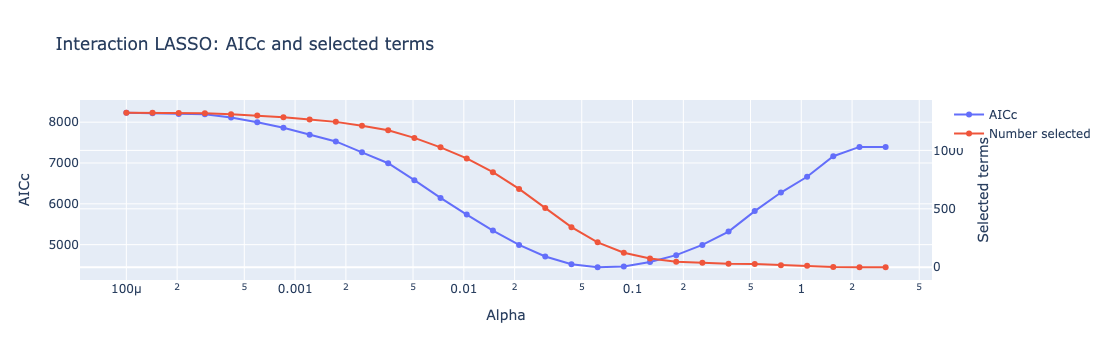

Full-sample AICc alpha (linear): 0.03039195382313198
Full-sample AICc alpha (quadratic): 0.043444122987293686
Full-sample AICc alpha (interaction): 0.06210169418915616


In [ ]:
# Select the AICc-optimal alpha using the full training sample
linear_full_selection = select_alpha_by_aicc(X_linear, y, alphas)
quadratic_full_selection = select_alpha_by_aicc(X_quadratic, y, alphas)
interaction_full_selection = select_alpha_by_aicc(X_interaction, y, alphas)


# Visualize the AICc path and model sparsity for the interaction LASSO
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=alphas,
    y=interaction_full_selection["aicc_values"],
    mode="lines+markers",
    name="AICc"
))
fig.add_trace(go.Scatter(
    x=alphas,
    y=interaction_full_selection["all_selected_counts"],
    mode="lines+markers",
    name="Number selected",
    yaxis="y2"
))
fig.update_layout(
    title="Interaction LASSO: AICc and selected terms",
    xaxis=dict(title="Alpha", type="log"),
    yaxis=dict(title="AICc"),
    yaxis2=dict(
        title="Selected terms",
        overlaying="y",
        side="right"
    )
)
fig.show()

# Report the full-sample AICc-optimal alpha for each specification
print("Full-sample AICc alpha (linear):",
      linear_full_selection["best_alpha"])
print("Full-sample AICc alpha (quadratic):",
      quadratic_full_selection["best_alpha"])
print("Full-sample AICc alpha (interaction):",
      interaction_full_selection["best_alpha"])


### Week 4 Pipeline + GridSearchCV check

The teacher also demonstrated `Pipeline + GridSearchCV`. This diagnostic checks whether CV selects an interaction penalty in the same broad region as AICc. It is not counted as an additional final model.


In [ ]:
# Set up a standardized LASSO pipeline for cross-validation
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(max_iter=20000))
])

param_grid = {"model__alpha": alphas}

# Select alpha by five-fold cross-validation using mean squared error
grid = GridSearchCV(
    pipe,
    param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1
)
grid.fit(X_interaction, y)

# Compare the alpha selected by AICc with the cross-validation choice
print("Interaction alpha selected by AICc:",
      interaction_full_selection["best_alpha"])
print("Interaction alpha selected by GridSearchCV:",
      grid.best_params_["model__alpha"])
print("Best GridSearchCV MSE:", -grid.best_score_)


Interaction alpha selected by AICc: 0.06210169418915616
Interaction alpha selected by GridSearchCV: 0.06210169418915616
Best GridSearchCV MSE: 6.5374660569369585


## Part 7 — Assignment 4 controls and FWL residualisation

Let (C) be the 50 original predictors and (Z) the 1,275 nonlinear candidates:

[
Y=C\beta+Z\gamma+\varepsilon.
]

Within each training fold, calculate (widetilde Y=Y-widehat E(Ymid C)) and (widetilde Z=Z-widehat E(Zmid C)), then apply LASSO to (widetilde Y) and (widetilde Z). After selection, OLS is refitted on the original controls plus selected raw nonlinear terms.

Week 8 residualised one variable at a time. Here, `LinearRegression` projects all columns of (Z) on (C) simultaneously. This is the same OLS operation applied in matrix form and is necessary for 1,275 candidates.


In [ ]:
def fit_controlled_nonlinear_model(C_train, Z_train, y_train):
    # Regress Y on controls and retain the residual
    model_y = LinearRegression()
    model_y.fit(C_train, y_train)
    y_residual = (
        y_train.to_numpy() - model_y.predict(C_train)
    )

    # Regress every nonlinear candidate on the same controls
    model_z = LinearRegression()
    model_z.fit(C_train, Z_train)
    Z_residual = pd.DataFrame(
        Z_train.to_numpy() - model_z.predict(C_train),
        columns=Z_train.columns,
        index=Z_train.index
    )

    # LASSO + AICc on residualised nonlinear information
    selection = select_alpha_by_aicc(
        Z_residual,
        pd.Series(y_residual, index=y_train.index),
        alphas,
        fixed_parameters=C_train.shape[1]
    )
    selected_terms = selection["selected_features"]

    # Post-LASSO OLS using controls and selected raw nonlinear terms
    final_design = pd.concat(
        [
            C_train.reset_index(drop=True),
            Z_train[selected_terms].reset_index(drop=True)
        ],
        axis=1
    )
    final_model = LinearRegression()
    final_model.fit(final_design, y_train.to_numpy())

    return {
        "model": final_model,
        "selected_terms": selected_terms,
        "best_alpha": selection["best_alpha"],
        "aicc_values": selection["aicc_values"],
        "selected_count": len(selected_terms)
    }


# Combine the controls with the selected nonlinear terms for prediction
def make_controlled_design(C, Z, selected_terms):
    return pd.concat(
        [
            C.reset_index(drop=True),
            Z[selected_terms].reset_index(drop=True)
        ],
        axis=1
    )


In [ ]:
# Evaluate the controlled nonlinear model using five-fold out-of-sample prediction
oof_controlled = np.empty(len(y))
controlled_fold_mse = []
controlled_fold_alphas = []
controlled_fold_terms = []

for fold_number, (train_indices, test_indices) in enumerate(
    folds, start=1
):
    # Fit and select nonlinear terms using only the training observations in each fold
    fitted = fit_controlled_nonlinear_model(
        X_linear.iloc[train_indices],
        Z_nonlinear.iloc[train_indices],
        y.iloc[train_indices]
    )

    validation_design = make_controlled_design(
        X_linear.iloc[test_indices],
        Z_nonlinear.iloc[test_indices],
        fitted["selected_terms"]
    )
    prediction = fitted["model"].predict(validation_design)
    oof_controlled[test_indices] = prediction

    fold_mse = mean_squared_error(
        y.iloc[test_indices], prediction
    )
    controlled_fold_mse.append(fold_mse)
    controlled_fold_alphas.append(fitted["best_alpha"])
    controlled_fold_terms.append(fitted["selected_terms"])

    print(
        f"Controlled model — fold {fold_number}: "
        f"alpha={fitted['best_alpha']:.6f}, "
        f"selected nonlinear terms={fitted['selected_count']}, "
        f"MSE={fold_mse:.4f}"
    )

# Summarize the out-of-sample predictive performance across all five folds
controlled_result = summarize_oof(
    "Controlled nonlinear model",
    y,
    oof_controlled,
    controlled_fold_mse
)

pd.DataFrame([controlled_result]).round(4)


Controlled model — fold 1: alpha=0.088772, selected nonlinear terms=121, MSE=6.8714
Controlled model — fold 2: alpha=0.088772, selected nonlinear terms=101, MSE=6.4868
Controlled model — fold 3: alpha=0.062102, selected nonlinear terms=194, MSE=7.7385
Controlled model — fold 4: alpha=0.088772, selected nonlinear terms=111, MSE=7.7459
Controlled model — fold 5: alpha=0.088772, selected nonlinear terms=118, MSE=7.2478


,Model,Gaussian deviance,CV MSE,CV RMSE,OOS R2,Fold MSE SD
0,Controlled nonlinear model,17323.4312,7.2181,2.6867,0.6682,0.491


### Selection stability

A nonlinear term selected in several folds is more stable than one selected once. This is descriptive and does not alter the validation predictions.


--- Most stable controlled nonlinear terms ---
   Nonlinear term  Folds selected
0       X10_x_X32               5
1       X10_x_X42               5
2       X11_x_X42               5
3       X11_x_X43               5
4       X12_x_X42               5
5          X13_sq               5
6       X15_x_X17               5
7       X15_x_X42               5
8       X16_x_X30               5
9       X16_x_X42               5
10       X1_x_X42               5
11      X20_x_X42               5
12      X22_x_X42               5
13      X23_x_X38               5
14      X23_x_X43               5
15      X25_x_X32               5
16      X25_x_X49               5
17         X26_sq               5
18      X26_x_X34               5
19      X26_x_X42               5


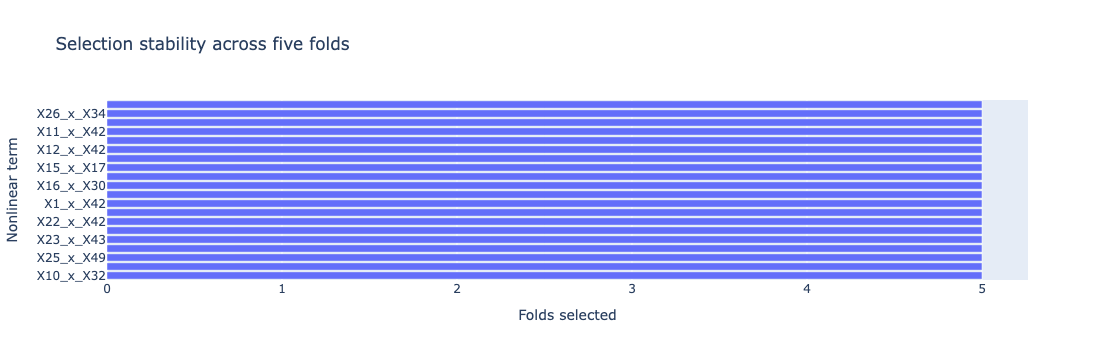

In [ ]:
# Count how often each nonlinear term is selected across the five folds
selection_frequency = Counter(
    term
    for fold_terms in controlled_fold_terms
    for term in fold_terms
)

stability_df = pd.DataFrame(
    selection_frequency.items(),
    columns=["Nonlinear term", "Folds selected"]
).sort_values(
    ["Folds selected", "Nonlinear term"],
    ascending=[False, True]
).reset_index(drop=True)

print("--- Most stable controlled nonlinear terms ---")
print(stability_df.head(20))

# Visualize the most frequently selected nonlinear terms to assess selection stability
if len(stability_df) > 0:
    plot_stability = stability_df.head(20).sort_values(
        "Folds selected"
    )
    fig = px.bar(
        plot_stability,
        x="Folds selected",
        y="Nonlinear term",
        orientation="h",
        title="Selection stability across five folds"
    )
    fig.update_xaxes(dtick=1)
    fig.show()


## Additional comparison — Interaction Ridge and Elastic Net

Both models use the same 1,325 candidate terms as Interaction LASSO. Ridge applies an L2 penalty; Elastic Net combines L1 and L2 penalties to explore regularisation under correlated features.

Each outer training fold uses an inner five-fold GridSearchCV to tune parameters. Scaling is inside the pipeline. The outer validation outcomes are excluded from tuning. Existing LASSO models retain their fold-specific AICc tuning, so the table compares complete modelling procedures, not penalty types alone. No causal interpretation is intended.

Ridge does not perform sparse variable selection. Elastic Net may set coefficients to zero. The new searches use CV rather than the LASSO nonzero-count AICc approximation. Full searches can take time on 1,325 features.


In [ ]:
# Same interaction feature set and outer folds as the LASSO comparisons.
# Inner CV chooses hyperparameters; outer folds evaluate the full procedure.
inner_cv = KFold(n_splits=5, shuffle=True, random_state=43)
ridge_alphas = np.logspace(-3, 5, 17)
elastic_net_alphas = np.logspace(-4, 0.5, 15)
l1_ratios = [0.1, 0.5, 0.9, 1.0]  # 1.0 is the LASSO endpoint

# Build standardized Ridge or Elastic Net models with hyperparameter tuning
def make_regularized_search(kind, cv):
    if kind == "ridge":
        estimator = Ridge(solver="lsqr", tol=1e-6)
        parameter_grid = {"model__alpha": ridge_alphas}
    elif kind == "elastic_net":
        estimator = ElasticNet(max_iter=20000, tol=1e-4)
        parameter_grid = {
            "model__alpha": elastic_net_alphas,
            "model__l1_ratio": l1_ratios
        }
    else:
        raise ValueError("kind must be ridge or elastic_net")

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", estimator)
    ])
    return GridSearchCV(
        pipeline, parameter_grid,
        scoring="neg_mean_squared_error", cv=cv,
        n_jobs=1, refit=True, error_score="raise"
    )

# Check whether the selected alpha lies on the search-grid boundary
def warn_grid_boundary(search, kind):
    grid = ridge_alphas if kind == "ridge" else elastic_net_alphas
    chosen = search.best_params_["model__alpha"]
    if chosen == grid[0] or chosen == grid[-1]:
        warnings.warn(
            f"{kind}: best alpha={chosen:g} is on the grid boundary. "
            "Consider expanding the grid and repeating validation."
        )

# Generate out-of-fold predictions using nested cross-validation
def regularized_oof(X, y, kind, model_name):
    predictions = np.empty(len(y))
    fold_mse = []
    fold_parameters = []

    for fold_number, (train_indices, valid_indices) in enumerate(folds, 1):
        search = make_regularized_search(kind, inner_cv)
        search.fit(X.iloc[train_indices], y.iloc[train_indices])
        prediction = search.predict(X.iloc[valid_indices])
        predictions[valid_indices] = prediction
        mse = mean_squared_error(y.iloc[valid_indices], prediction)
        fold_mse.append(mse)
        fold_parameters.append(search.best_params_)
        print(f"{model_name} — fold {fold_number}: "
              f"{search.best_params_}, MSE={mse:.4f}")
        warn_grid_boundary(search, kind)

    result = summarize_oof(model_name, y, predictions, fold_mse)
    details = {"fold_mse": fold_mse, "fold_parameters": fold_parameters}
    return result, predictions, details


In [ ]:
# Fit Ridge and Elastic Net models and compare their out-of-fold performance with LASSO
ridge_result, oof_ridge, ridge_details = regularized_oof(
    X_interaction, y, "ridge", "Interaction Ridge"
)
elastic_net_result, oof_elastic_net, elastic_net_details = regularized_oof(
    X_interaction, y, "elastic_net", "Interaction Elastic Net"
)

pd.DataFrame([interaction_result, ridge_result, elastic_net_result]).sort_values(
    "CV RMSE"
).round(4)


Interaction Ridge — fold 1: {'model__alpha': np.float64(1000.0)}, MSE=8.8706
Interaction Ridge — fold 2: {'model__alpha': np.float64(1000.0)}, MSE=8.7603
Interaction Ridge — fold 3: {'model__alpha': np.float64(1000.0)}, MSE=9.6044
Interaction Ridge — fold 4: {'model__alpha': np.float64(1000.0)}, MSE=8.9238
Interaction Ridge — fold 5: {'model__alpha': np.float64(1000.0)}, MSE=9.3427
Interaction Elastic Net — fold 1: {'model__alpha': np.float64(0.07813707376518102), 'model__l1_ratio': 1.0}, MSE=6.2622
Interaction Elastic Net — fold 2: {'model__alpha': np.float64(0.07813707376518102), 'model__l1_ratio': 1.0}, MSE=6.0540
Interaction Elastic Net — fold 3: {'model__alpha': np.float64(0.07813707376518102), 'model__l1_ratio': 1.0}, MSE=6.5973
Interaction Elastic Net — fold 4: {'model__alpha': np.float64(0.07813707376518102), 'model__l1_ratio': 1.0}, MSE=7.0320
Interaction Elastic Net — fold 5: {'model__alpha': np.float64(0.07813707376518102), 'model__l1_ratio': 1.0}, MSE=6.8725


,Model,Gaussian deviance,CV MSE,CV RMSE,OOS R2,Fold MSE SD
0,Interaction LASSO,15741.6845,6.5590,2.5611,0.6985,0.3272
2,Interaction Elastic Net,15752.6209,6.5636,2.5620,0.6983,0.3651
1,Interaction Ridge,21840.8869,9.1004,3.0167,0.5817,0.3201


## Part 8 — Model averaging and stacking

Equal averaging combines quadratic, interaction and controlled predictions without estimating meta-parameters. Linear stacking uses `LinearRegression` on their OOS predictions. A second five-fold loop evaluates the stacker. No SciPy optimisation, non-negative restriction, custom estimator or nested CV is used.

The existing stacking score is exploratory: the second CV loop does not independently validate the complete stacking procedure. It is excluded from automatic final-model selection.


In [ ]:
# Equal-weight average
oof_average = np.mean(
    np.column_stack([
        oof_quadratic,
        oof_interaction,
        oof_controlled
    ]),
    axis=1
)
average_fold_mse = [
    mean_squared_error(y.iloc[test_indices], oof_average[test_indices])
    for _, test_indices in folds
]
average_result = summarize_oof(
    "Equal-weight average", y, oof_average, average_fold_mse
)

# Linear stacking
stack_X = np.column_stack([
    oof_quadratic,
    oof_interaction,
    oof_controlled
])
oof_stacking = np.empty(len(y))
stacking_fold_mse = []

for fold_number, (train_indices, test_indices) in enumerate(
    folds, start=1
):
    stacking_model = LinearRegression()
    stacking_model.fit(stack_X[train_indices], y.iloc[train_indices])
    prediction = stacking_model.predict(stack_X[test_indices])
    oof_stacking[test_indices] = prediction

    fold_mse = mean_squared_error(
        y.iloc[test_indices], prediction
    )
    stacking_fold_mse.append(fold_mse)
    print(f"Stacking — fold {fold_number}: MSE={fold_mse:.4f}")

stacking_result = summarize_oof(
    "Linear stacking", y, oof_stacking, stacking_fold_mse
)


Stacking — fold 1: MSE=6.2170
Stacking — fold 2: MSE=6.0194
Stacking — fold 3: MSE=6.5995
Stacking — fold 4: MSE=7.2158
Stacking — fold 5: MSE=6.6997


## Part 9 — Final OOS comparison

The final model is selected only by the lowest five-fold OOS RMSE. The other metrics help evaluate fit and stability.


In [ ]:
# Compare all candidate models using five-fold out-of-sample performance
results_table = pd.DataFrame([
    linear_result,
    quadratic_result,
    interaction_result,
    controlled_result,
    average_result,
    ridge_result,
    elastic_net_result
]).sort_values("CV RMSE").reset_index(drop=True)

print("--- Five-fold OOS model comparison ---")
print(results_table.round(4))

# Select the model with the lowest cross-validated RMSE
best_model_name = results_table.loc[0, "Model"]
best_rmse = results_table.loc[0, "CV RMSE"]

print("\nSelected model:", best_model_name)
print("Selected model CV RMSE:", round(best_rmse, 4))


--- Five-fold OOS model comparison ---
                        Model  Gaussian deviance  CV MSE  CV RMSE  OOS R2  \
0           Interaction LASSO         15741.6845  6.5590   2.5611  0.6985   
1     Interaction Elastic Net         15752.6209  6.5636   2.5620  0.6983   
2        Equal-weight average         16270.1220  6.7792   2.6037  0.6884   
3  Controlled nonlinear model         17323.4312  7.2181   2.6867  0.6682   
4             Quadratic LASSO         20706.6127  8.6278   2.9373  0.6034   
5           Interaction Ridge         21840.8869  9.1004   3.0167  0.5817   
6                Linear LASSO         22458.4849  9.3577   3.0590  0.5699   

   Fold MSE SD  
0       0.3272  
1       0.3651  
2       0.3442  
3       0.4910  
4       0.5714  
5       0.3201  
6       0.5727  

Selected model: Interaction LASSO
Selected model CV RMSE: 2.5611


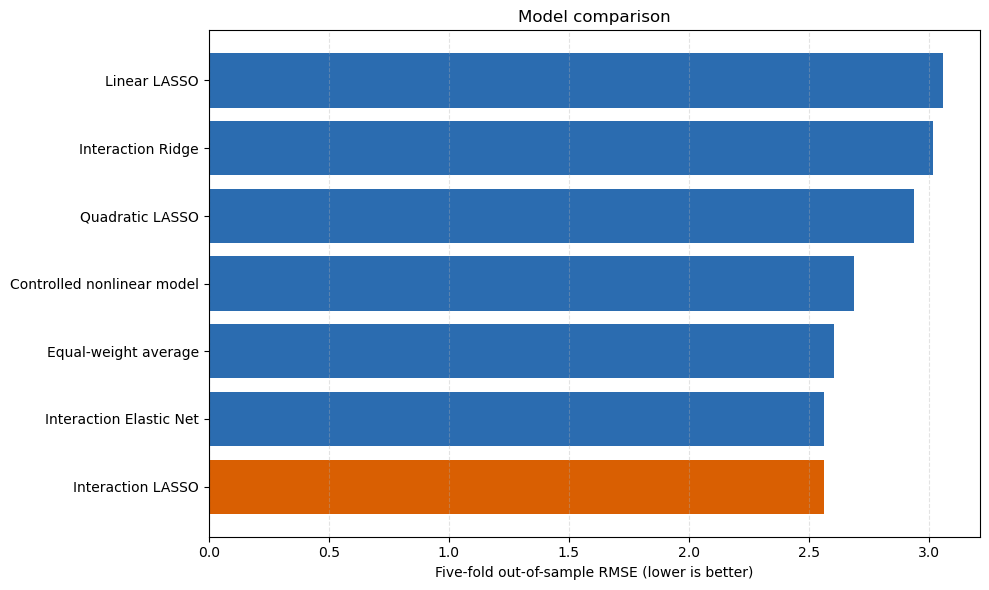

In [ ]:
# Figure 1: OOS RMSE comparison
plot_results = results_table.sort_values("CV RMSE")
colors = [
    "#D95F02" if name == best_model_name else "#2B6CB0"
    for name in plot_results["Model"]
]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_results["Model"], plot_results["CV RMSE"], color=colors)
ax.set_xlabel("Five-fold out-of-sample RMSE (lower is better)")
ax.set_title("Model comparison")
ax.grid(axis="x", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.savefig(
    "assignment04_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


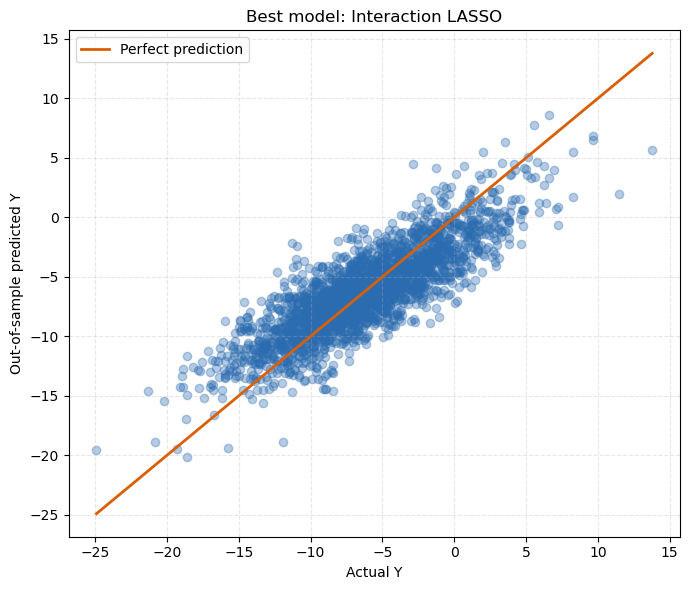

In [ ]:
# Figure 2: actual versus OOS predictions
oof_prediction_dict = {
    "Linear LASSO": oof_linear,
    "Quadratic LASSO": oof_quadratic,
    "Interaction LASSO": oof_interaction,
    "Controlled nonlinear model": oof_controlled,
    "Equal-weight average": oof_average,
    "Interaction Ridge": oof_ridge,
    "Interaction Elastic Net": oof_elastic_net,
    "Linear stacking": oof_stacking
}
best_oof_prediction = oof_prediction_dict[best_model_name]

lower_limit = min(y.min(), best_oof_prediction.min())
upper_limit = max(y.max(), best_oof_prediction.max())

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y, best_oof_prediction, alpha=0.35, color="#2B6CB0")
ax.plot(
    [lower_limit, upper_limit],
    [lower_limit, upper_limit],
    color="#D95F02",
    linewidth=2,
    label="Perfect prediction"
)
ax.set_xlabel("Actual Y")
ax.set_ylabel("Out-of-sample predicted Y")
ax.set_title(f"Best model: {best_model_name}")
ax.legend()
ax.grid(linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(
    "assignment04_best_model_oos.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## Part 10 — Full-sample refit

After OOS comparison, every required base model is refitted on all training observations before test prediction.


In [ ]:
# Refit the candidate models on the full labelled training sample
def fit_full_lasso(X, y, selection):
    model = make_lasso_pipeline(selection["best_alpha"])
    model.fit(X, y)
    return model


linear_full_model = fit_full_lasso(
    X_linear, y, linear_full_selection
)
quadratic_full_model = fit_full_lasso(
    X_quadratic, y, quadratic_full_selection
)
interaction_full_model = fit_full_lasso(
    X_interaction, y, interaction_full_selection
)
controlled_full = fit_controlled_nonlinear_model(
    X_linear, Z_nonlinear, y
)

stacking_full_model = LinearRegression()
stacking_full_model.fit(stack_X, y)

print("Final controlled-model alpha:",
      controlled_full["best_alpha"])
print("Final number of controlled nonlinear terms:",
      controlled_full["selected_count"])
print("Final stacking coefficients:",
      stacking_full_model.coef_)
print("Final stacking intercept:",
      stacking_full_model.intercept_)

# Tune on all labelled training data and refit for Kaggle test prediction.
# These training-CV scores are not replacements for the outer OOF scores.
ridge_full_search = make_regularized_search("ridge", inner_cv)
ridge_full_search.fit(X_interaction, y)
ridge_full_model = ridge_full_search.best_estimator_

elastic_net_full_search = make_regularized_search("elastic_net", inner_cv)
elastic_net_full_search.fit(X_interaction, y)
elastic_net_full_model = elastic_net_full_search.best_estimator_

print("Full-sample Ridge parameters:", ridge_full_search.best_params_)
print("Full-sample Elastic Net parameters:", elastic_net_full_search.best_params_)
warn_grid_boundary(ridge_full_search, "ridge")
warn_grid_boundary(elastic_net_full_search, "elastic_net")


Final controlled-model alpha: 0.06210169418915616
Final number of controlled nonlinear terms: 184
Final stacking coefficients: [-0.01188296  1.05930156  0.01871245]
Final stacking intercept: 0.4097627738714653
Full-sample Ridge parameters: {'model__alpha': np.float64(1000.0)}
Full-sample Elastic Net parameters: {'model__alpha': np.float64(0.07813707376518102), 'model__l1_ratio': 1.0}


## Part 11 — Test prediction

The test data receive exactly the same transformations as the training data. No test outcome is used.


In [ ]:
# Reuse the structurally checked test sample.

X_linear_test, X_quadratic_test, X_interaction_test, Z_nonlinear_test = build_feature_sets(
    test_df, feature_cols
)

# Generate test-set predictions from each fitted candidate model
test_prediction_linear = linear_full_model.predict(X_linear_test)
test_prediction_quadratic = quadratic_full_model.predict(X_quadratic_test)
test_prediction_interaction = interaction_full_model.predict(X_interaction_test)

controlled_test_design = make_controlled_design(
    X_linear_test,
    Z_nonlinear_test,
    controlled_full["selected_terms"]
)
test_prediction_controlled = controlled_full["model"].predict(
    controlled_test_design
)

test_prediction_average = np.mean(
    np.column_stack([
        test_prediction_quadratic,
        test_prediction_interaction,
        test_prediction_controlled
    ]),
    axis=1
)

test_stack_X = np.column_stack([
    test_prediction_quadratic,
    test_prediction_interaction,
    test_prediction_controlled
])
test_prediction_stacking = stacking_full_model.predict(test_stack_X)

test_prediction_ridge = ridge_full_model.predict(X_interaction_test)
test_prediction_elastic_net = elastic_net_full_model.predict(X_interaction_test)

test_prediction_dict = {
    "Linear LASSO": test_prediction_linear,
    "Quadratic LASSO": test_prediction_quadratic,
    "Interaction LASSO": test_prediction_interaction,
    "Controlled nonlinear model": test_prediction_controlled,
    "Equal-weight average": test_prediction_average,
    "Interaction Ridge": test_prediction_ridge,
    "Interaction Elastic Net": test_prediction_elastic_net,
    "Linear stacking": test_prediction_stacking
}

# Use the best OOS-performing model to generate the final test prediction
test_df["Y_pred"] = test_prediction_dict[best_model_name]

print("Preview of test predictions:")
print(test_df[["ID", "Y_pred"]].head())


Preview of test predictions:
     ID     Y_pred
0  2400  -5.075163
1  2401  -1.391456
2  2402  -4.941739
3  2403  -7.157793
4  2404 -10.144863


## Part 12 — Generate submission file

This is the same submission structure and path used previously.


In [ ]:
# Create a submission DataFrame with 'ID' and predicted 'Y'
submission_df = pd.DataFrame({
    "ID": test_df["ID"],
    "Y": test_df["Y_pred"]
})

assert len(submission_df) == len(test_df)
assert submission_df["ID"].is_unique
assert np.isfinite(submission_df["Y"].to_numpy()).all()
assert submission_df["ID"].equals(test_df["ID"])

# Save the submission file to the week01 folder
output_path = "./week01/my_submission.csv"
submission_df.to_csv(output_path, index=False)

print(f"Submission file generated at: {output_path}")
print("\nFirst 5 rows of the submission:")
print(submission_df.head())


Submission file generated at: ./week01/my_submission.csv

First 5 rows of the submission:
     ID          Y
0  2400  -5.075163
1  2401  -1.391456
2  2402  -4.941739
3  2403  -7.157793
4  2404 -10.144863


## Part 13 — Submit and read leaderboard

These cells follow the earlier assignment structure. Run submission only after checking the preview. Take a screenshot of **My Submissions** showing the score.


In [ ]:
# Set True only when you intend to submit the newly generated predictions.
SUBMIT_TO_KAGGLE = False
if SUBMIT_TO_KAGGLE:
    api.competition_submit(
        file_name="./week01/my_submission.csv",
        message=f"Assignment 4 - {best_model_name}",
        competition=COMPETITION_ID
    )
    print("Submission uploaded. Check My Submissions for the score.")
else:
    print("CSV generated; Kaggle submission is switched off.")


CSV generated; Kaggle submission is switched off.


In [ ]:
# Retrieve the leaderboard for the same competition
leaderboard = api.competition_leaderboard_view(COMPETITION_ID)

# Print the raw leaderboard response
print("--- Raw Leaderboard Response ---")
print(leaderboard)


Next Page Token = CfDJ8OasvsPNS7VMiSwiBm2YVpOY5YDZRHUqqdggyzdjNoLOEMBx95cF_34C1pne6q27_mHJmPS5BChnwmZ6h01eTd0
--- Raw Leaderboard Response ---
[{"teamId": 16644298, "teamName": "Group 4", "submissionDate": "2026-09-03T06:52:29.023Z", "score": "3.50354"}, {"teamId": 16645142, "teamName": "Jaspal Kaur", "submissionDate": "2026-09-15T14:54:29.320Z", "score": "3.50354"}, {"teamId": 16745853, "teamName": "claud", "submissionDate": "2026-09-03T07:58:20.626Z", "score": "3.50354"}, {"teamId": 16645143, "teamName": "Claudia Zhang", "submissionDate": "2026-08-20T06:57:50.210Z", "score": "3.59711"}, {"teamId": 16641219, "teamName": "kaiwen xue", "submissionDate": "2026-09-03T11:39:41.736Z", "score": "3.67234"}, {"teamId": 16738479, "teamName": "G-4", "submissionDate": "2026-09-15T04:23:16.360Z", "score": "3.82439"}, {"teamId": 16644694, "teamName": "SHAKTI SURESH", "submissionDate": "2026-09-15T12:22:31.430Z", "score": "4.03952"}, {"teamId": 16616578, "teamName": "alemac2005", "submissionDate": "